# Diabetes Prediction with the 100,000-record Dataset

This notebook preserves the project workflow while adapting it to the new dataset. It covers inspection, justified cleaning, reasonable EDA, leakage-safe preprocessing, the three required models, evaluation, comparison, and persistence.

## 1. Import Libraries

The libraries below support tabular analysis, visualization, preprocessing, the two sklearn models, and the PyTorch neural network.

In [41]:
# Tools for working with files, tables, numbers, and charts
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tools used to prepare the data and train the sklearn models
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Metrics used later to compare the three models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
)

# PyTorch is used for the neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Using the same random seed makes the results easier to reproduce
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

sns.set_theme(style="whitegrid")


## 2. Load Dataset

The CSV is resolved relative to the notebook, making the workflow reproducible when run from the project root or notebook directory.

In [42]:
 # Store the path to the CSV file when the notebook is run from the project root.
DATA_PATH = Path("data/raw/diabetes_prediction_dataset.csv")

# Use the parent folder path when the notebook is run from the notebooks folder.
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/diabetes_prediction_dataset.csv")

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Show where the data came from so the input can be checked.
print(f"Dataset path: {DATA_PATH.resolve()}")

# Show the number of rows and columns in the dataset.
print(f"Shape: {df.shape}")

# Display the first five rows to check that the data loaded correctly.
df.head()


Dataset path: /home/bhairava/Projects/Diabetes-Prediction/data/raw/diabetes_prediction_dataset.csv
Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Initial Dataset Inspection

The target is `diabetes`. 

In [43]:
# Store the name of the column we want to predict.
TARGET = "diabetes"

# Stop the notebook early if the expected target column is missing.
assert TARGET in df.columns

# Display the column names, data types, and non-null counts.
print(df.info())

# Count missing values in every column.
print("\nMissing values:")
print(df.isna().sum())

# Count exact duplicate rows before cleaning.
print(f"\nDuplicate rows: {df.duplicated().sum():,}")

# Count the different values in every column.
print("\nUnique values:")
print(df.nunique())

# Show how many records belong to each target class.
print("\nTarget distribution:")
print(df[TARGET].value_counts())

# Show the target distribution as percentages as well.
print((df[TARGET].value_counts(normalize=True) * 100).round(2))


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3,854


## 4. Data Cleaning

There are no missing values, invalid categorical values, or non-positive measurements in this file. Exact duplicate records are removed because they repeat the same observation and can make evaluation over-optimistic. No other rows are removed without evidence of a data-entry problem.

In [44]:
# Store the numeric feature names for later plots and preprocessing.
NUMERIC_COLUMNS = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
]

# Store the binary feature names for later preprocessing.
BINARY_COLUMNS = ["hypertension", "heart_disease"]

# Show missing values so we know whether any rows need filling.
print("Missing values in each column:")
print(df.isna().sum())

# Count exact duplicate rows before removing them.
number_of_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {number_of_duplicates:,}")

# Show the categories found in the two text columns.
print("\nGender values:")
print(df["gender"].unique())
print("\nSmoking history values:")
print(df["smoking_history"].unique())

# Show the ranges of the main numeric measurements.
print("\nNumeric ranges:")
print(df[NUMERIC_COLUMNS].agg(["min", "max"]))

# Save the original number of rows so we can report the cleaning result.
rows_before = len(df)

# Remove exact duplicate records and reset the row numbers.
df = df.drop_duplicates().reset_index(drop=True)

# Report how many rows remain after cleaning.
print(f"\nRows before cleaning: {rows_before:,}")
print(f"Duplicate rows removed: {rows_before - len(df):,}")
print(f"Rows after cleaning: {len(df):,}")

# Confirm that the dataset has no missing values before modeling.
assert df.isna().sum().sum() == 0


Missing values in each column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3,854

Gender values:
<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

Smoking history values:
<ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

Numeric ranges:
       age    bmi  HbA1c_level  blood_glucose_level
min   0.08  10.01          3.5                   80
max  80.00  95.69          9.0                  300

Rows before cleaning: 100,000
Duplicate rows removed: 3,854
Rows after cleaning: 96,146


## 5. Exploratory Data Analysis

The target is strongly imbalanced, with diabetes positive in 8.5% of rows. The plots below use the cleaned data and focus on distributions and relationships that can inform preprocessing and model interpretation.

                       count unique     top   freq        mean        std  \
gender                 96146      3  Female  56161         NaN        NaN   
age                  96146.0    NaN     NaN    NaN   41.794326  22.462948   
hypertension         96146.0    NaN     NaN    NaN    0.077601   0.267544   
heart_disease        96146.0    NaN     NaN    NaN    0.040803   0.197833   
smoking_history        96146      6   never  34398         NaN        NaN   
bmi                  96146.0    NaN     NaN    NaN   27.321461   6.767716   
HbA1c_level          96146.0    NaN     NaN    NaN    5.532609   1.073232   
blood_glucose_level  96146.0    NaN     NaN    NaN  138.218231  40.909771   
diabetes             96146.0    NaN     NaN    NaN     0.08822   0.283616   

                       min    25%    50%    75%    max  
gender                 NaN    NaN    NaN    NaN    NaN  
age                   0.08   24.0   43.0   59.0   80.0  
hypertension           0.0    0.0    0.0    0.0    1.0  
h

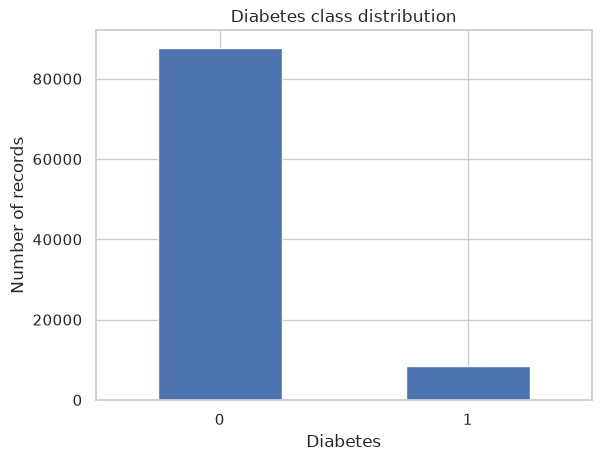

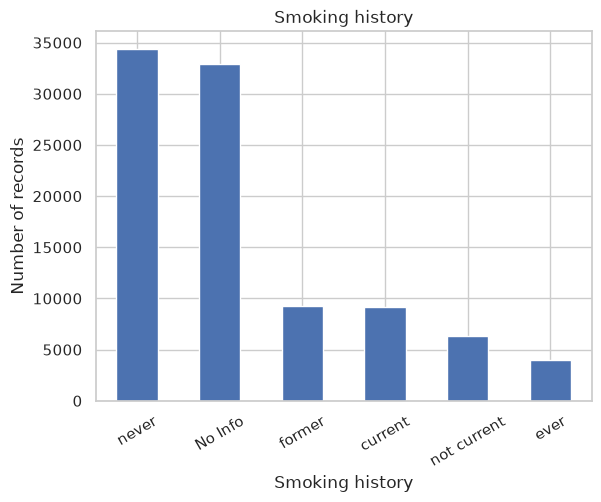

In [45]:
# Print basic summary statistics before making the plots.
print(df.describe(include="all").transpose())

# Count how many records are in each diabetes class.
diabetes_counts = df[TARGET].value_counts()

# Draw a simple bar chart of the two diabetes classes.
diabetes_counts.plot(kind="bar", title="Diabetes class distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.show()

# Count the records in each smoking-history category.
smoking_counts = df["smoking_history"].value_counts()

# Draw a simple bar chart of the smoking-history categories.
smoking_counts.plot(kind="bar", title="Smoking history")
plt.xlabel("Smoking history")
plt.ylabel("Number of records")
plt.xticks(rotation=30)
plt.show()


### EDA interpretation: class and category counts

The first bar chart shows the number of records with and without diabetes. The positive class is smaller, so accuracy alone may not tell the whole story. That is why the model section also reports precision, recall, F1-score, ROC-AUC, and confusion matrices.

The second bar chart shows how often each smoking-history category appears. It helps us understand the data before modeling. The chart does not prove that smoking history causes diabetes. The category is converted into numbers later using one-hot encoding.

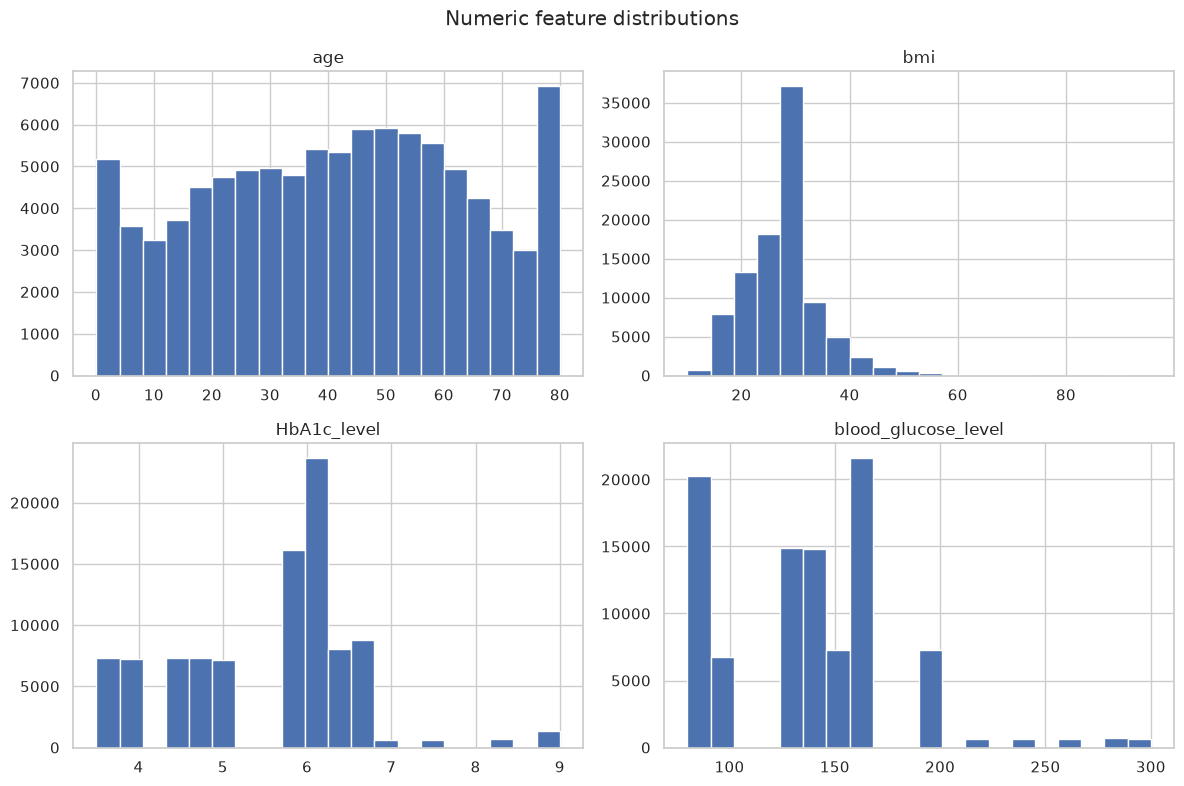

In [46]:
# Draw a basic histogram for each numeric feature.
df[NUMERIC_COLUMNS].hist(
    figsize=(12, 8),
    bins=20,
)

# Add a heading above the four histograms.
plt.suptitle("Numeric feature distributions")

# Keep the subplot labels from overlapping.
plt.tight_layout()

# Display the histograms.
plt.show()


### EDA interpretation: numeric feature histograms

These simple histograms show the spread of age, BMI, HbA1c level, and blood glucose level. They help us see the typical values and whether a feature has a long tail or unusual values.

The values are kept because they are within plausible ranges for this dataset. StandardScaler is used later for Logistic Regression and the neural network so features with larger numeric values do not dominate those models.

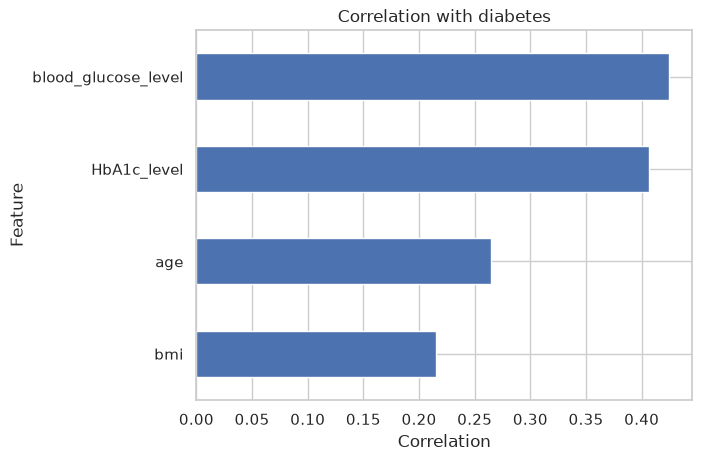

In [47]:
# Calculate the correlation of each numeric feature with the target.
correlations_with_target = df[NUMERIC_COLUMNS + [TARGET]].corr()[TARGET]

# Remove the target's correlation with itself because it is always 1.
correlations_with_target = correlations_with_target.drop(TARGET)

# Sort the correlations so the chart is easier to read.
correlations_with_target = correlations_with_target.sort_values()

# Draw a simple horizontal bar chart of the correlations.
correlations_with_target.plot(
    kind="barh",
    title="Correlation with diabetes",
)
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()


### EDA interpretation: correlation bar chart

This chart shows the correlation between each numeric feature and the diabetes target. A positive value means that the feature tends to increase when the target is higher; a negative value means the opposite. Values close to zero show a weak linear relationship.

Correlation does not prove cause and effect, and it does not find every nonlinear pattern. We keep all available features and let the three models learn from them.

## 6. Data Preprocessing and Train/Test Split

The split happens before fitting preprocessing to prevent information from the test set leaking into training. Numeric features are standardized for Logistic Regression and PyTorch; categorical features are one-hot encoded. The same fitted transformer is shared by all three models.

In [48]:
# Separate the input columns from the target column.
X = df.drop(columns=TARGET)
y = df[TARGET].astype(np.int64)

# Split the data before fitting the preprocessing steps.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Keep the measurements and binary indicators in the numeric group.
numeric_features = NUMERIC_COLUMNS + BINARY_COLUMNS

# Keep the text columns in the categorical group.
categorical_features = ["gender", "smoking_history"]

# Standardize numeric features and one-hot encode text features.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

# Learn preprocessing values only from the training data.
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessing to the test data.
X_test_processed = preprocessor.transform(X_test)

# Get readable names for the transformed columns.
feature_names = preprocessor.get_feature_names_out()

# Put the processed arrays back into DataFrames for easier inspection.
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index,
)

# Show how many rows and processed features each split contains.
print(X_train_processed.shape, X_test_processed.shape)


(76916, 15) (19230, 15)


## 7. Logistic Regression

This uses sklearn’s established implementation. `max_iter=1000` gives the solver enough iterations for convergence after preprocessing, and `class_weight="balanced"` accounts for the imbalanced target without duplicating samples.

In [49]:
# Build a pipeline that preprocesses the raw data before fitting Logistic Regression.
logistic_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Train Logistic Regression using the training rows only.
logistic_pipeline.fit(X_train, y_train)

# Predict the class for each test row.
logistic_pred = logistic_pipeline.predict(X_test)

# Get the probability assigned to the positive diabetes class.
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


## 8. Random Forest

Random Forest captures nonlinear feature interactions. The moderate tree count and constrained depth keep training practical for 80,000 training records, while `n_jobs=-1` uses available CPU cores.

In [50]:
# Build a pipeline that preprocesses the raw data before fitting Random Forest.
random_forest_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=16,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train Random Forest using the same training rows as Logistic Regression.
random_forest_pipeline.fit(X_train, y_train)

# Predict the class for each test row.
random_forest_pred = random_forest_pipeline.predict(X_test)

# Get the probability assigned to the positive diabetes class.
random_forest_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]


## 9. PyTorch Neural Network

The network uses two hidden layers with ReLU activations and one logit output. `BCEWithLogitsLoss` combines a numerically stable sigmoid and binary cross-entropy; mini-batches make training practical for this dataset.

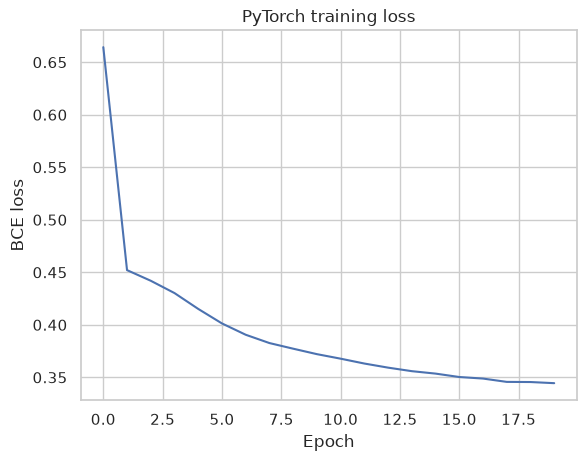

In [51]:
class DiabetesNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, features):
        return self.network(features)

X_train_tensor = torch.tensor(X_train_processed.to_numpy(dtype=np.float32))
y_train_tensor = torch.tensor(y_train.to_numpy(dtype=np.float32)).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_processed.to_numpy(dtype=np.float32))
y_test_tensor = torch.tensor(y_test.to_numpy(dtype=np.float32)).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=512, shuffle=True)
neural_network = DiabetesNN(X_train_processed.shape[1])
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32))
optimizer = optim.Adam(neural_network.parameters(), lr=0.001)
loss_history = []

for epoch in range(20):
    neural_network.train()
    epoch_loss = 0.0
    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()
        loss = loss_function(neural_network(batch_features), batch_targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_features)
    loss_history.append(epoch_loss / len(train_loader.dataset))

neural_network.eval()
with torch.no_grad():
    neural_network_prob = torch.sigmoid(neural_network(X_test_tensor)).numpy().ravel()
neural_network_pred = (neural_network_prob >= 0.5).astype(int)
plt.plot(loss_history)
plt.title("PyTorch training loss")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.show()


## 10. Model Evaluation and Comparison

All models are evaluated on the same held-out test set. Because only 8.5% of cleaned records are positive, recall, F1, ROC-AUC, and the confusion matrix are important alongside accuracy.

In [52]:
# Calculate all evaluation scores for one model.
def calculate_metrics(model_name, actual_values, predicted_values, probabilities):
    # Calculate the percentage of all predictions that are correct.
    accuracy = accuracy_score(actual_values, predicted_values)

    # Calculate how often positive predictions are correct.
    precision = precision_score(
        actual_values,
        predicted_values,
        zero_division=0,
    )

    # Calculate how many actual positive cases were found.
    recall = recall_score(
        actual_values,
        predicted_values,
        zero_division=0,
    )

    # Combine precision and recall into one balanced score.
    f1 = f1_score(
        actual_values,
        predicted_values,
        zero_division=0,
    )

    # Measure ranking quality using the predicted probabilities.
    roc_auc = roc_auc_score(actual_values, probabilities)

    # Return the scores in a row that can be added to a table.
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
    }


# Calculate scores for Logistic Regression.
logistic_results = calculate_metrics(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob,
)

# Calculate scores for Random Forest.
random_forest_results = calculate_metrics(
    "Random Forest",
    y_test,
    random_forest_pred,
    random_forest_prob,
)

# Calculate scores for the PyTorch neural network.
neural_network_results = calculate_metrics(
    "PyTorch Neural Network",
    y_test,
    neural_network_pred,
    neural_network_prob,
)

# Put the three result rows into one comparison table.
results = pd.DataFrame(
    [
        logistic_results,
        random_forest_results,
        neural_network_results,
    ]
)
results = results.set_index("Model")

# Print the comparison table rounded to four decimal places.
print("Model comparison:")
print(results.round(4))

# Print the confusion matrix for Logistic Regression.
print("\nLogistic Regression confusion matrix:")
print(confusion_matrix(y_test, logistic_pred))

# Print the confusion matrix for Random Forest.
print("\nRandom Forest confusion matrix:")
print(confusion_matrix(y_test, random_forest_pred))

# Print the confusion matrix for the PyTorch neural network.
print("\nPyTorch Neural Network confusion matrix:")
print(confusion_matrix(y_test, neural_network_pred))


Model comparison:
                        Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                               
Logistic Regression       0.8845     0.4251  0.8797  0.5732   0.9601
Random Forest             0.9212     0.5329  0.8603  0.6581   0.9740
PyTorch Neural Network    0.8789     0.4153  0.9151  0.5713   0.9728

Logistic Regression confusion matrix:
[[15516  2018]
 [  204  1492]]

Random Forest confusion matrix:
[[16255  1279]
 [  237  1459]]

PyTorch Neural Network confusion matrix:
[[15349  2185]
 [  144  1552]]


## 11. Final Pipeline and Saving

The sklearn pipelines include preprocessing and their model, so raw records can be passed directly to `predict` and `predict_proba`. The PyTorch model uses the separately saved shared preprocessor because its training loop is outside sklearn’s Pipeline API.

In [53]:
# Choose the folder where trained model files will be saved.
models_folder = Path("../models")
if not models_folder.exists():
    models_folder = Path("models")

# Create the folder if it does not already exist.
models_folder.mkdir(exist_ok=True)

# Save the complete Logistic Regression pipeline.
joblib.dump(
    logistic_pipeline,
    models_folder / "diabetes_logistic_pipeline.pkl",
)

# Save the complete Random Forest pipeline.
joblib.dump(
    random_forest_pipeline,
    models_folder / "diabetes_random_forest_pipeline.pkl",
)

# Save the shared preprocessing object for the PyTorch model.
joblib.dump(
    preprocessor,
    models_folder / "diabetes_preprocessor.pkl",
)

# Save the PyTorch weights and the information needed to rebuild its input layer.
torch.save(
    {
        "model_state_dict": neural_network.state_dict(),
        "input_size": X_train_processed.shape[1],
        "feature_names": list(feature_names),
    },
    models_folder / "diabetes_neural_network.pt",
)

# Read the ROC-AUC score for Logistic Regression.
logistic_auc = results.loc["Logistic Regression", "ROC-AUC"]

# Read the ROC-AUC score for Random Forest.
random_forest_auc = results.loc["Random Forest", "ROC-AUC"]

# Select the better sklearn pipeline using ROC-AUC.
# Convert NumPy scalar values to regular Python floats before comparing.
if float(logistic_auc) >= float(random_forest_auc):
    best_model_name = "Logistic Regression"
    best_pipeline = logistic_pipeline
else:
    best_model_name = "Random Forest"
    best_pipeline = random_forest_pipeline

# Save the selected pipeline for the Streamlit application.
joblib.dump(
    best_pipeline,
    models_folder / "diabetes_prediction_pipeline.pkl",
)

# Tell the user where the files were saved.
print(f"Saved model files in: {models_folder.resolve()}")
print(f"Best sklearn model by ROC-AUC: {best_model_name}")


Saved model files in: /home/bhairava/Projects/Diabetes-Prediction/models
Best sklearn model by ROC-AUC: Random Forest
